## 🎮 Video Game Sales Analysis

### 📌 Objective
Analyze global video game sales data to uncover patterns across **genre, platform, publisher, and region**, and generate **data-driven recommendations** for game developers.

### 🎯 Key Questions
- Which publishers dominate the market?
- Which genres generate the highest sales?
- How do preferences differ across regions?
- Which platforms perform best globally and regionally?

#### 🧾 1. IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set(style='whitegrid')

#### 📥 2. DATA LOADING

In [4]:
df = pd.read_csv('vgsales.csv')
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [9]:
df.shape

(16291, 11)

📌 Insight

Dataset contains ~16K rows of video game sales data across multiple regions.

#### 🧠 3. DATA UNDERSTANDING

In [10]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  int64  
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.5+ MB


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000
mean,8290.190228,2006.405561,0.265647,0.147731,0.078833,0.048426,0.540910
std,4792.654450,5.832412,0.822432,0.509303,0.311879,0.190083,1.567345
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4132.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8292.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12439.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


The dataset includes:
- Categorical variables: Name, Platform, Genre, Publisher  
- Numerical variables: Sales across regions and globally  
- Year of release

#### 🧹 4. DATA CLEANING

In [ ]:
# Check missing values
df.isnull().sum()

# Drop missing values in critical columns
df = df.dropna(subset=['Year', 'Publisher'])

In [13]:
# Convert Year
df['Year'] = df['Year'].astype(int)

# Check duplicate
df.duplicated().sum()

np.int64(0)

### ✅ Cleaning Summary
- Removed missing values in Year & Publisher  
- Ensured correct data types  
- No duplicate data found  

#### 📊 5. EXPLORATORY DATA ANALYSIS (EDA)

##### 🎮 5.1 Top Publishers

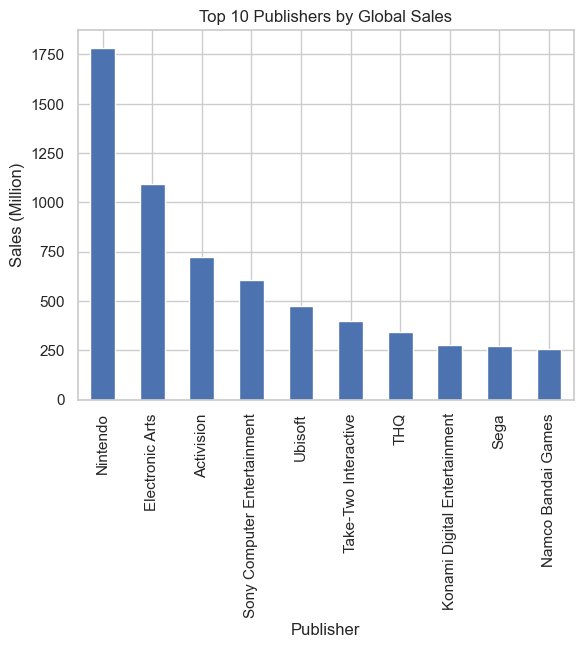

In [7]:
top_publishers = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_publishers.plot(kind='bar')
plt.title('Top 10 Publishers by Global Sales')
plt.xlabel('Publisher')
plt.ylabel('Sales (Million)')
plt.show()

📌 Insight
- **Nintendo dominates the market significantly**, far ahead of competitors  
- Indicates strong IP ownership and global market penetration  

##### 🎯 5.2 Genre Analysis

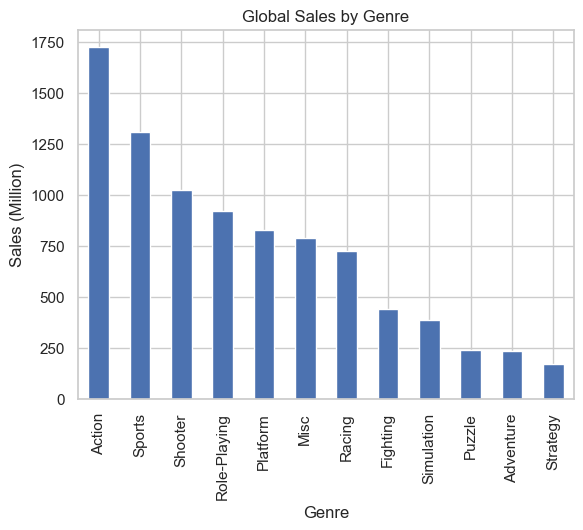

In [14]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure()
genre_sales.plot(kind='bar')
plt.title('Global Sales by Genre')
plt.xlabel('Genre')
plt.ylabel('Sales (Million)')
plt.show()

📌 Insight
- **Action genre leads global sales**, followed by Sports and Shooter  
- Suggests high demand for fast-paced, mass-market games  

##### 🌍 5.3 Regional Sales Distribution

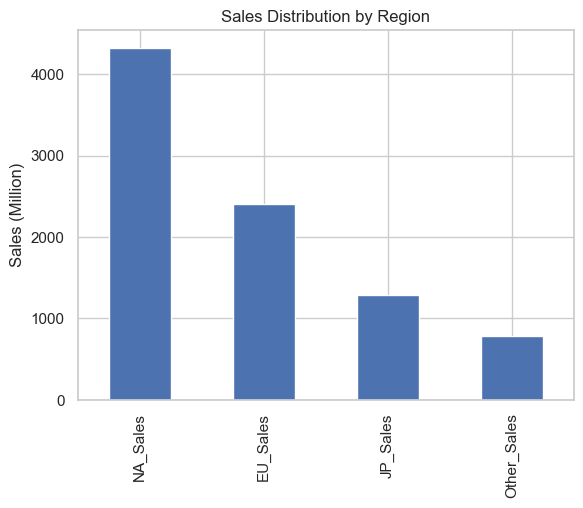

In [15]:
region_sales = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

plt.figure()
region_sales.plot(kind='bar')
plt.title('Sales Distribution by Region')
plt.ylabel('Sales (Million)')
plt.show()

📌 Insight
- North America and Europe dominate total sales  
- Japan shows distinct behavior → niche preferences  

##### 📊 5.4 Trend Over Time

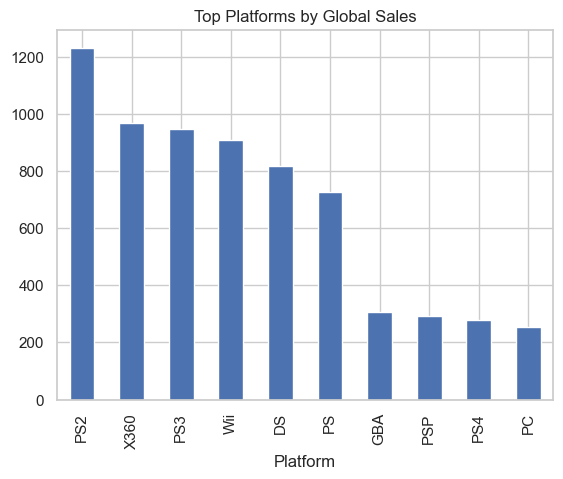

In [21]:
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure()
platform_sales.plot(kind='bar')
plt.title('Top Platforms by Global Sales')
plt.show()

📌 Insight (TOP PLATFORM)
- **PS2 emerges as the top-performing platform globally**
- Followed by X360, PS3, and Wii  
- Indicates that console ecosystems dominate over PC in total sales  

💡 Business Insight
- Platform selection is **critical to commercial success**  
- Developers should prioritize platforms with strong user bases and historical performance  

##### 🌍 5.5 Platform per Region

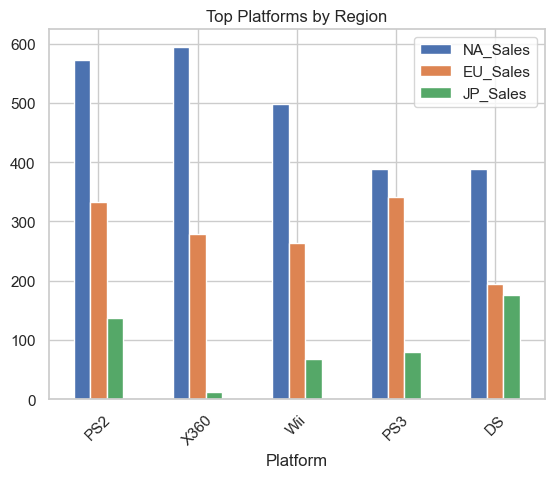

In [22]:
platform_region = df.groupby('Platform')[['NA_Sales','EU_Sales','JP_Sales']].sum()

top_platforms = platform_region.sum(axis=1).sort_values(ascending=False).head(5).index

platform_region.loc[top_platforms].plot(kind='bar')
plt.title('Top Platforms by Region')
plt.xticks(rotation=45)
plt.show()

📌 Insight
- NA dominated by X360  
- EU dominated by PlayStation platforms  
- Japan dominated by Nintendo platforms  

👉 Each region has distinct platform preferences  

##### 📅 5.6 Trend Game Release

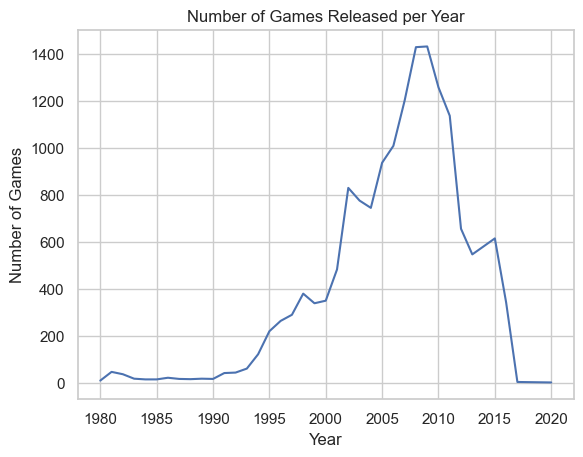

In [16]:
games_per_year = df['Year'].value_counts().sort_index()

plt.figure()
games_per_year.plot()
plt.title('Number of Games Released per Year')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.show()

📌 Insight
- Peak occurred around **2008–2009**, reflecting industry expansion era  

##### 🔗 5.7 Correlation Between Regions

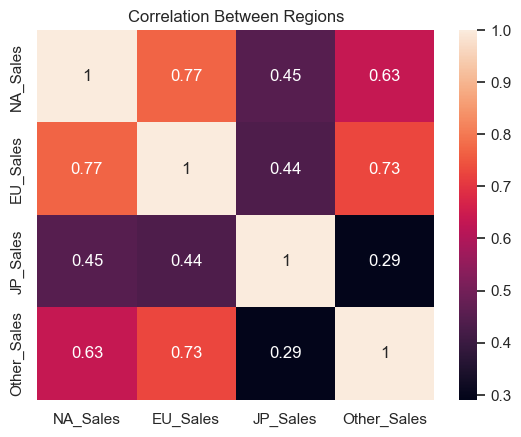

In [18]:
corr = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title('Correlation Between Regions')
plt.show()

📌 Insight
- Strong correlation between NA & EU → similar market behavior  
- Japan is less correlated → unique market dynamics  

#### 🧪 6. Statistical Analysis

🎯 T-Test (PC vs X360)

In [19]:
pc = df[df['Platform'] == 'PC']['Global_Sales']
x360 = df[df['Platform'] == 'X360']['Global_Sales']

t_stat, p_value = stats.ttest_ind(pc, x360)

print("P-value:", p_value)

P-value: 3.409027620394838e-19


📌 Insight
- p-value < 0.05 → **Significant difference between platforms**
- Platform choice significantly affects sales performance  

#### 🔍 7. Key Insights

- Nintendo dominates global publisher market  
- Action is the most profitable genre  
- Platform choice significantly impacts sales  
- Strong regional differences exist in gaming preferences  
- PS2 is the highest-selling platform globally  

#### 🚀 8. Business Recommendations

- Focus on Action-based or hybrid genres  
- Tailor game releases based on regional preferences  
- Prioritize high-performing platforms (PS2, X360, PS3)  
- Use data-driven strategy for platform selection  